In [28]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import StateSpace, lsim

In [48]:
m = 1
k = 3
c = 2

# The variables below will remain constant...
dt = 0.01
t = np.arange(0, 10, dt)
F = np.ones_like(t)

In [49]:
def get_state_model(m, k, c):
    A = np.array([
        [0, 1],
        [-k/m, -c/m]
    ])
    
    B = np.array([
        [0],
        [1/m]
    ])
    
    C = np.array([0, 1])
    
    D = np.array([0])

    return StateSpace(A, B, C, D)

In [67]:
M = [2 ** i for i in range(0, 10, 2)]
K = [2 ** i for i in range(0, 10, 2)]
C = [2 ** i for i in range(0, 10, 2)]

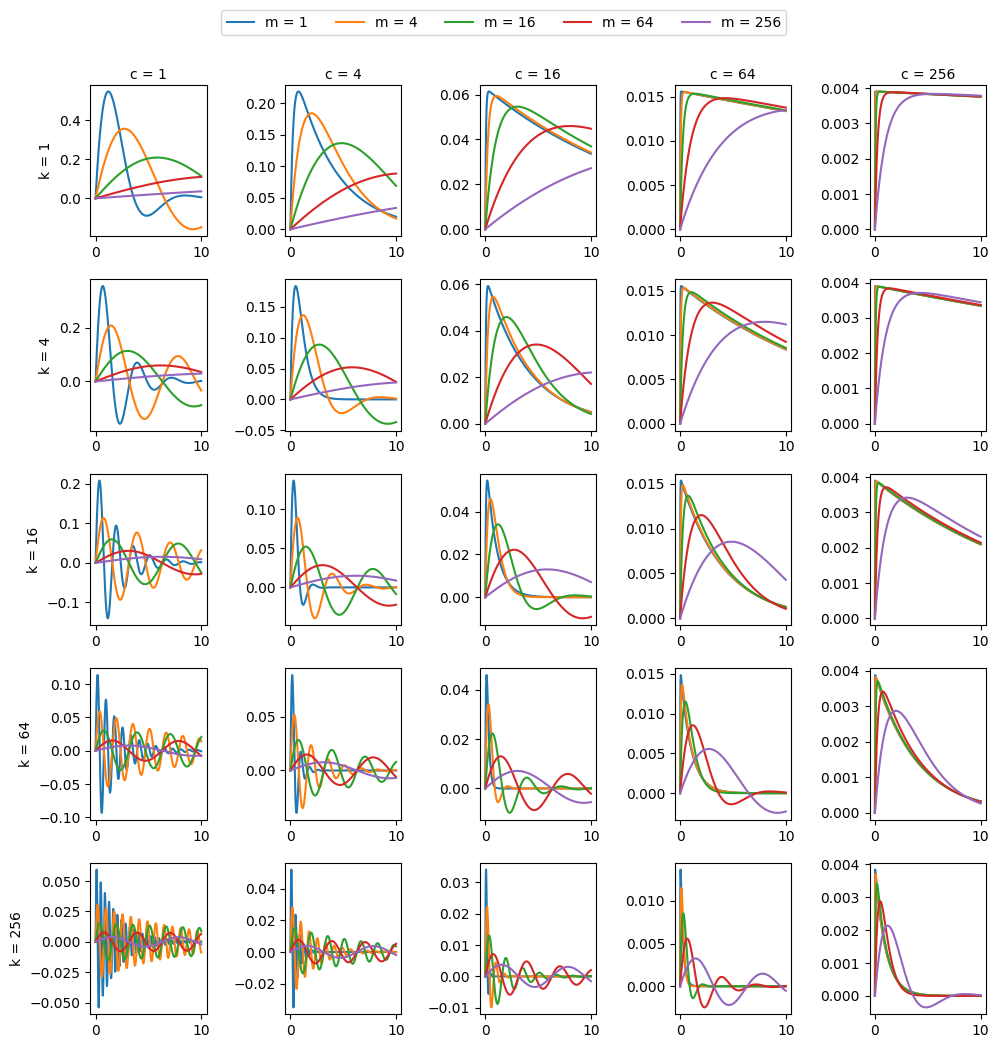

In [107]:
nrows, ncols = 5, 5

fig, axs = plt.subplots(nrows, ncols, figsize=(10, 10))
for i in range(nrows):
    for j in range(nrows):
        for k in range(len(M)):
            sys = get_state_model(M[k], K[i], C[j])
            t_out, y_out, x_out = lsim(sys, U=F, T=t)
            axs[i][j].plot(t_out, y_out, label=f"m = {M[k]}")
        if i == 0:
            axs[i][j].set_xlabel(f"c = {C[j]}")
            axs[i][j].xaxis.set_label_position("top")
        if j == 0:
            axs[i][j].set_ylabel(f"k = {K[i]}")

handles, labels = [], []

for handle, label in zip(*axs[0][0].get_legend_handles_labels()):
    handles.append(handle)
    labels.append(label)

fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=5, fancybox=True)
fig.tight_layout()
fig.savefig("all.png", bbox_inches="tight")

It seems that plotting for different mass scenario in the same plot is affecting understandibility greatly.

In [96]:
def plot_result(m, K, C, savepath):
    nrows, ncols = len(K), len(C)
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(10, 10))
    for i in range(nrows):
        for j in range(nrows):
            sys = get_state_model(m, K[i], C[j])
            t_out, y_out, x_out = lsim(sys, U=F, T=t)
            axs[i][j].plot(t_out, y_out)
            if i == 0:
                axs[i][j].set_xlabel(f"c = {C[j]}")
                axs[i][j].xaxis.set_label_position("top")
            if j == 0:
                axs[i][j].set_ylabel(f"k = {K[i]}")
    
    fig.suptitle(f"m = {m}")
    plt.tight_layout()
    plt.savefig(savepath)
    plt.show()

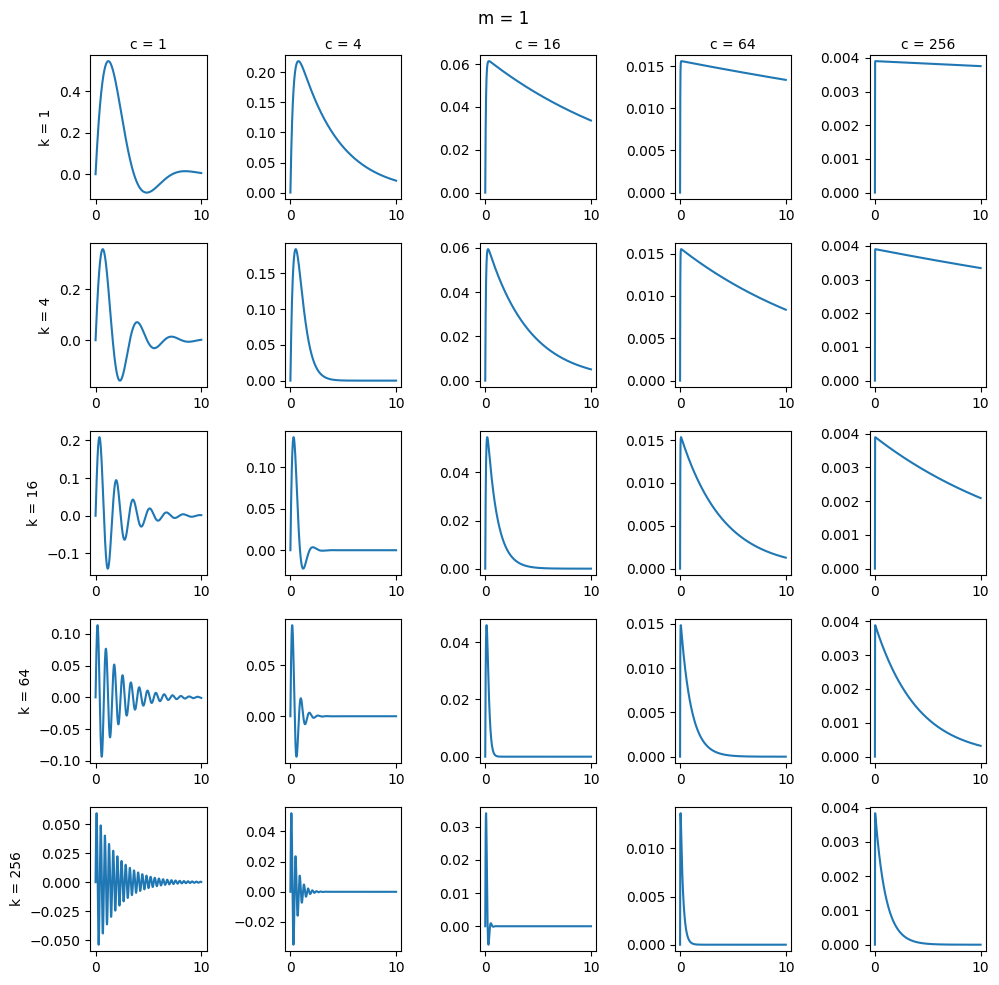

In [97]:
plot_result(M[0], K, C, "1.png")

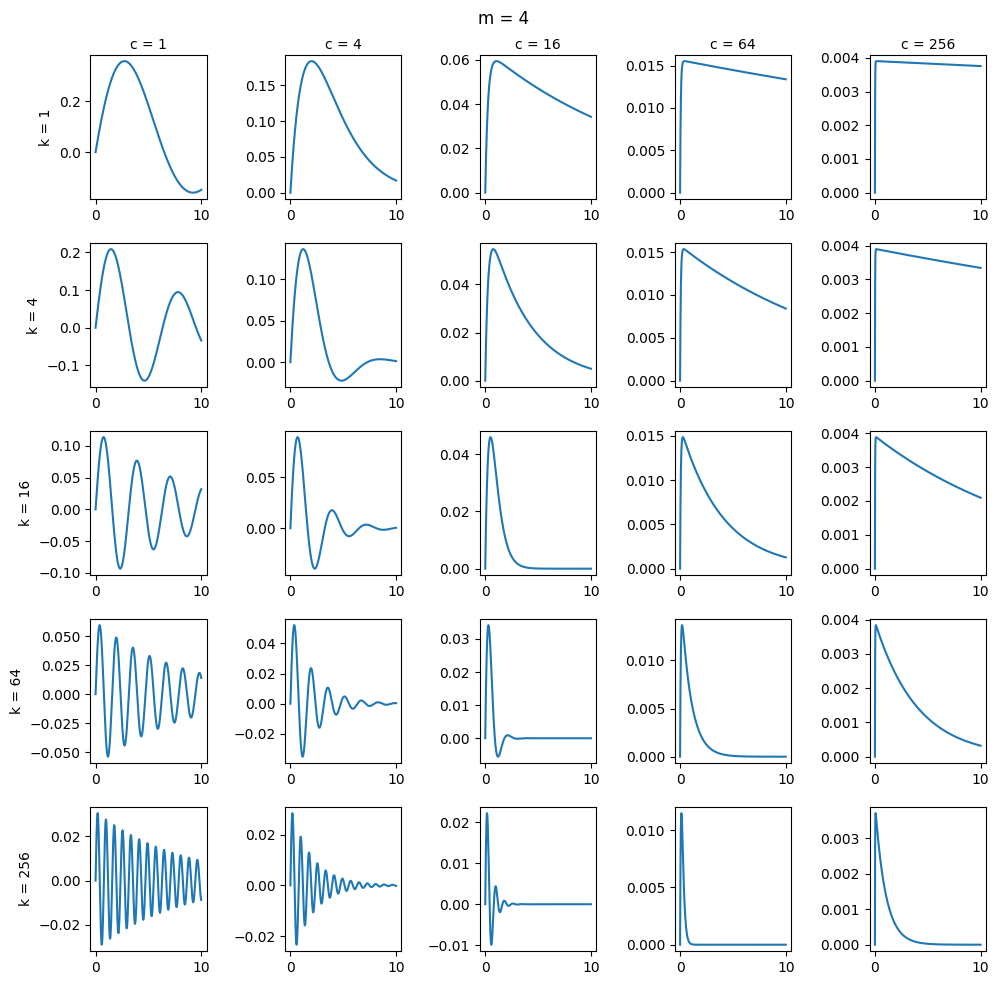

In [98]:
plot_result(M[1], K, C, "2.png")

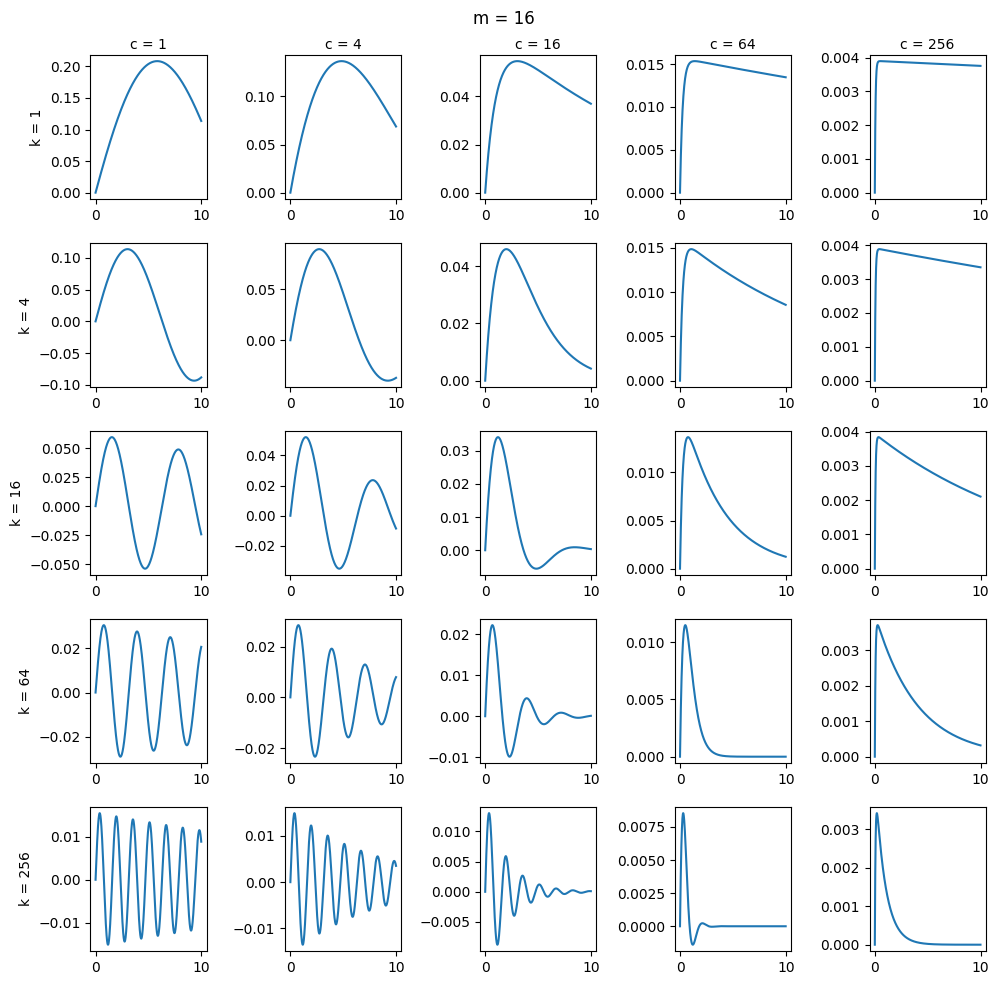

In [99]:
plot_result(M[2], K, C, "3.png")

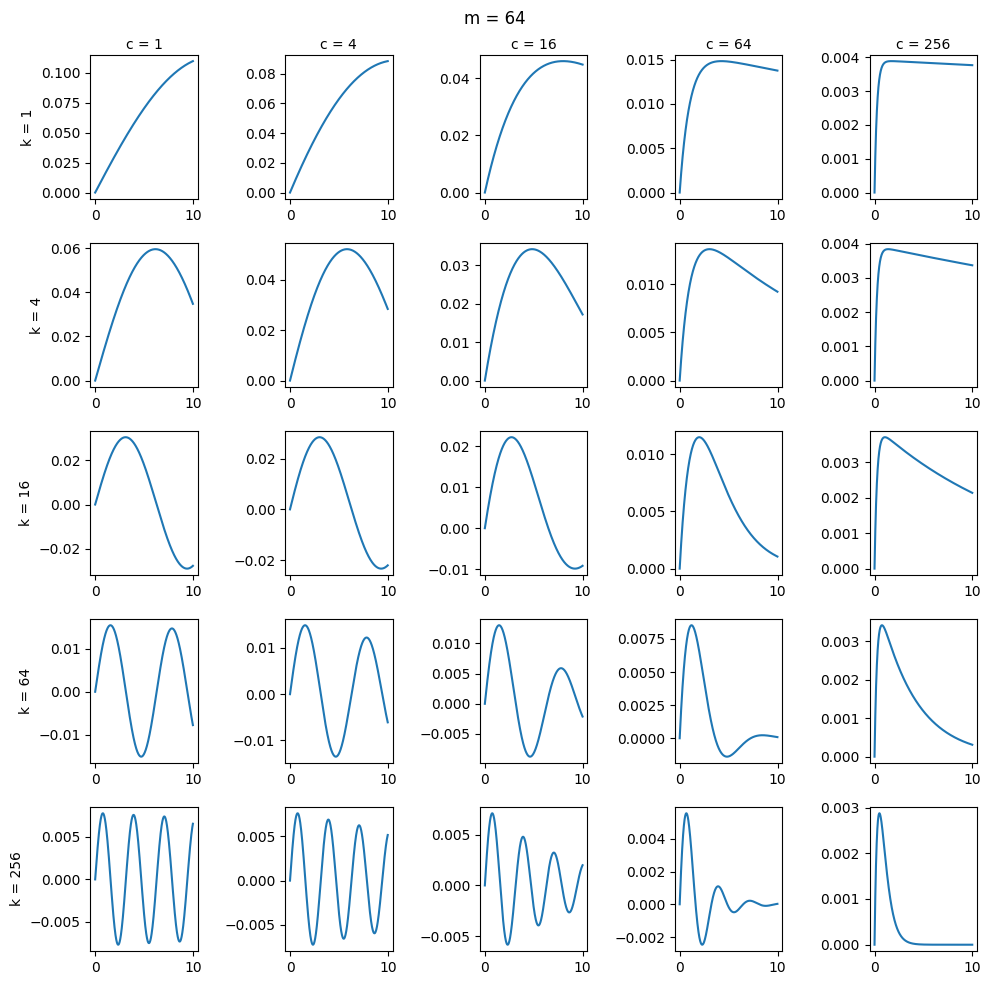

In [100]:
plot_result(M[3], K, C, "4.png")

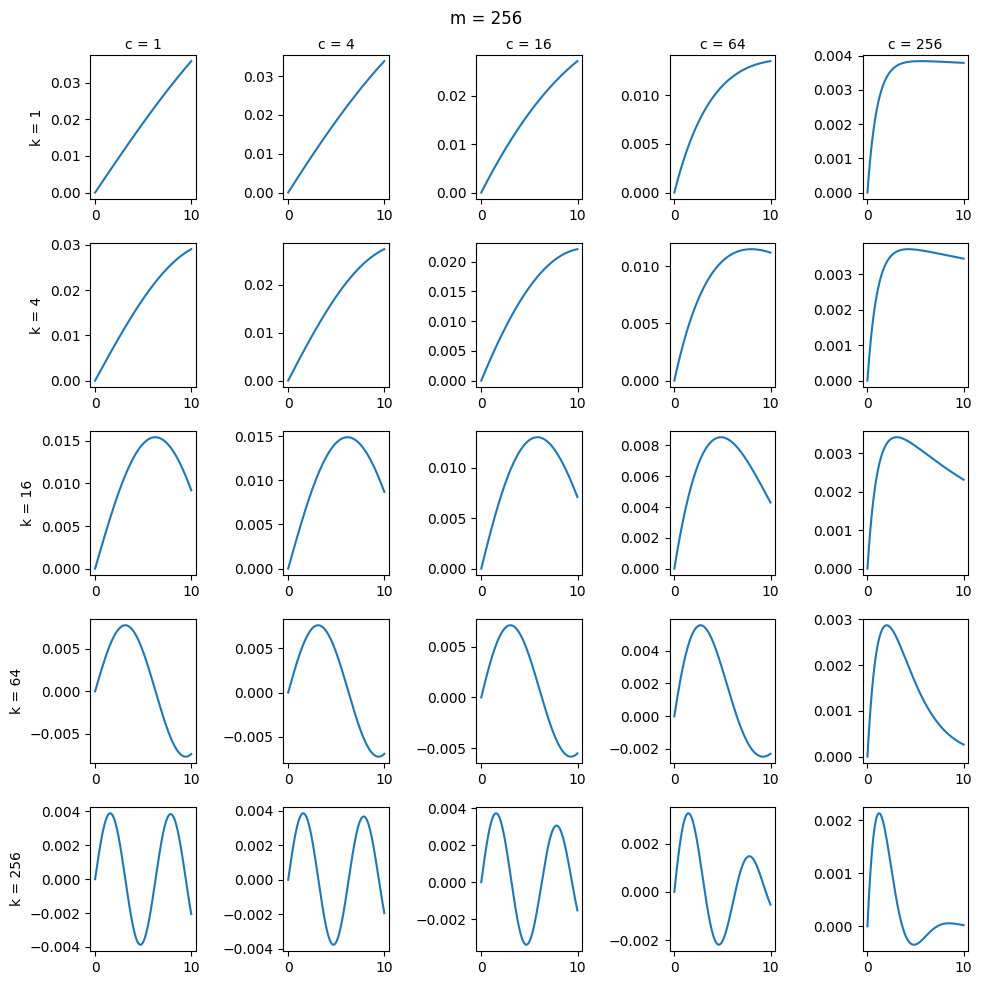

In [101]:
plot_result(M[4], K, C, "5.png")
